In [2]:
#importing reuired Libraries
pip install pandas numpy matplotlib seaborn scikit-learn openpyxl

Note: you may need to restart the kernel to use updated packages.


In [3]:
#importing the excel dataset
import pandas as pd

df = pd.read_excel("customer_segmentation_dataset.xlsx")

df.head()


,InvoiceNo,CustomerID,InvoiceDate,Quantity,UnitPrice,Country
0,INV-10001,CUST-1180,2023-11-30,8,187.47,Netherlands
1,INV-10002,CUST-1010,2023-10-22,3,166.41,Netherlands
2,INV-10003,CUST-1127,2023-07-18,2,58.54,Poland
3,INV-10004,CUST-1013,2023-01-02,4,167.41,Poland
4,INV-10005,CUST-1151,2023-12-01,8,71.43,Germany


In [4]:
#checking the columns in the dataset
df.columns

Index(['InvoiceNo', 'CustomerID', 'InvoiceDate', 'Quantity', 'UnitPrice',
       'Country'],
      dtype='object')

In [5]:
#creating a new Column TotalAmount
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

The dataset contains transactional customer data including invoice details, purchase quantity, unit price, and country.

A new variable TotalAmount was created to represent the total value of each transaction.

In [6]:
#the Column info of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    2000 non-null   object 
 1   CustomerID   2000 non-null   object 
 2   InvoiceDate  2000 non-null   object 
 3   Quantity     2000 non-null   int64  
 4   UnitPrice    2000 non-null   float64
 5   Country      2000 non-null   object 
 6   TotalAmount  2000 non-null   float64
dtypes: float64(2), int64(1), object(4)
memory usage: 109.5+ KB


In [8]:
#converting date data type
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [9]:
#checking missing value
df.isnull().sum()

InvoiceNo      0
CustomerID     0
InvoiceDate    0
Quantity       0
UnitPrice      0
Country        0
TotalAmount    0
dtype: int64

# Exploratory Data Analysis (EDA)

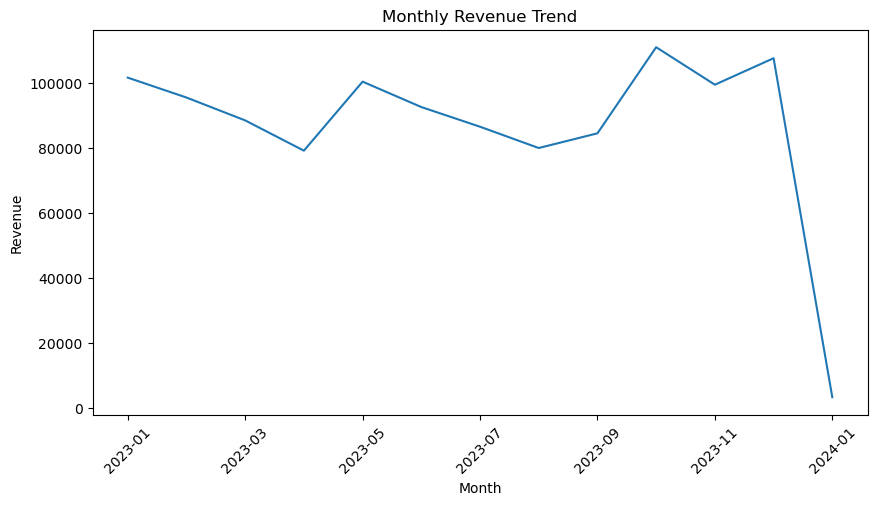

In [10]:
#Monthly Revenue Trend
import matplotlib.pyplot as plt

df["YearMonth"] = df["InvoiceDate"].dt.to_period("M").astype(str)

monthly_revenue = df.groupby("YearMonth")["TotalAmount"].sum()

plt.figure(figsize=(10,5))
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

🎯 Interpretation
The monthly revenue trend shows fluctuations over time, indicating variability in customer purchasing behavior. This may suggest seasonal demand patterns or changes in customer activity.

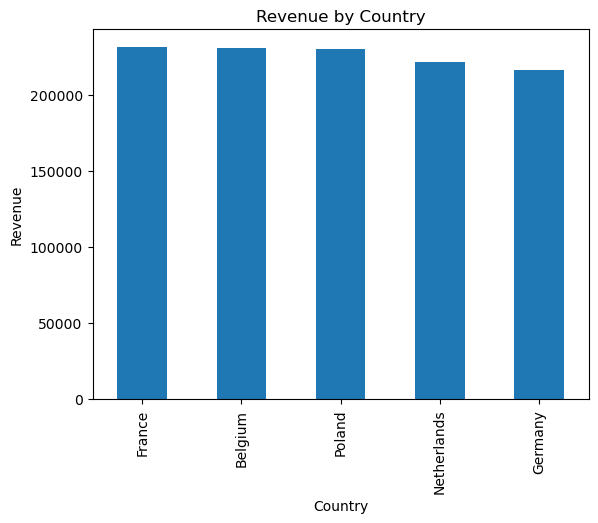

In [11]:
#Revenue by Country
country_revenue = df.groupby("Country")["TotalAmount"].sum().sort_values(ascending=False)

country_revenue.plot(kind="bar")
plt.title("Revenue by Country")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.show()

🎯 Interpretation

Revenue is distributed across multiple countries, with some countries contributing significantly more to total sales. This highlights key markets driving business performance.

# Customer-Level Features

In [12]:
#Creating snapshot date
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

In [13]:
#Building RFM features
customer_df = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,  # Recency
    "InvoiceNo": "count",                                     # Frequency
    "TotalAmount": "sum"                                      # Monetary
}).reset_index()

customer_df.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]

customer_df.head()

,CustomerID,Recency,Frequency,Monetary
0,CUST-1001,52,9,5113.01
1,CUST-1002,1,11,4377.92
2,CUST-1003,2,12,6737.57
3,CUST-1004,26,11,7043.91
4,CUST-1005,2,9,3540.17


Customer-level features were created using the RFM model:

Recency: days since last purchase
Frequency: number of transactions
Monetary: total spending

These metrics are widely used to analyze customer behavior and value.

# Rule-Based Segmentation

In [14]:
#Create customer segments
customer_df["Segment"] = pd.qcut(
    customer_df["Monetary"],
    q=3,
    labels=["Low Value", "Medium Value", "High Value"]
)

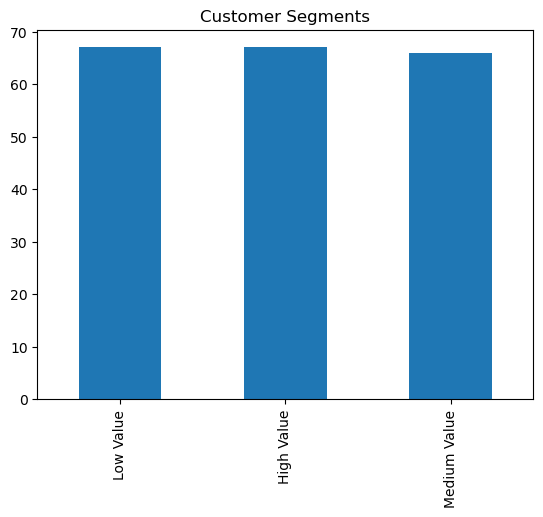

In [15]:
#Plot segments
customer_df["Segment"].value_counts().plot(kind="bar")
plt.title("Customer Segments")
plt.show()

🎯 Interpretation

Customers were segmented into three groups based on total spending.
High-value customers represent the most important group, contributing the largest share of revenue.

# K-Means Clustering

In [16]:
#Preparing data
from sklearn.preprocessing import StandardScaler

features = customer_df[["Recency", "Frequency", "Monetary"]]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [17]:
#Applying clustering
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
customer_df["Cluster"] = kmeans.fit_predict(scaled_features)

C:\Users\Toshiba Pc\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\Toshiba Pc\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


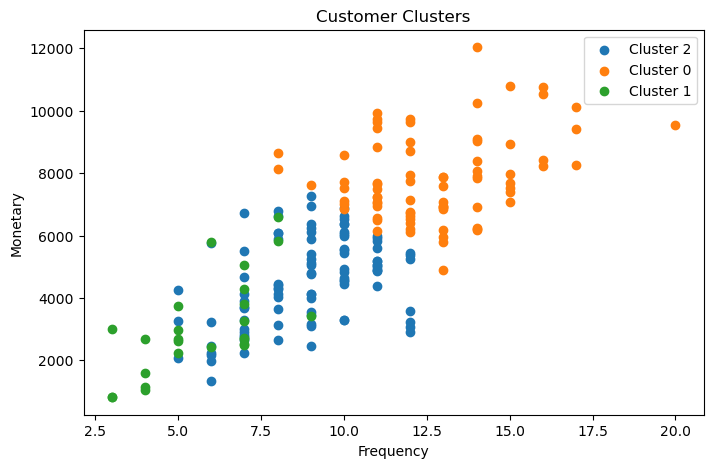

In [18]:
#Visualizing clusters
plt.figure(figsize=(8,5))

for cluster in customer_df["Cluster"].unique():
    subset = customer_df[customer_df["Cluster"] == cluster]
    plt.scatter(subset["Frequency"], subset["Monetary"], label=f"Cluster {cluster}")

plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.title("Customer Clusters")
plt.legend()
plt.show()

🎯 Interpretation

Clustering reveals distinct customer groups based on purchasing behavior.
Some clusters represent high-frequency, high-spending customers, while others represent low-engagement users.

In [19]:
#Exporting Results
customer_df.to_csv("customer_segmentation_results.csv", index=False)